# Lab Assignment

- Perform classification on the MNIST dataset using an ANN model

- You are permitted to conduct exploration of,

    - Preprocessing methods

    - Feature selection

    - ANN architecture

    - Activation functions

- The ANN is implemented using TensorFlow.

**Step 1 - Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

**Step 2 - Load MNIST Dataset**

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


**Step 3 - Preprocessing**

In [4]:
# Normalize pixels
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test  = X_test.reshape(-1, 28*28) / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

**Step 4 - Feature Selection using PCA**

In [5]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

**Step 5 - Build ANN Model**

In [6]:
input_dim = X_train_pca.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

**Step 6 - Compile Model**

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Step 7 - Train Model**

In [8]:
history = model.fit(
    X_train_pca, y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9048 - loss: 0.3430 - val_accuracy: 0.9565 - val_loss: 0.1487
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9681 - loss: 0.1090 - val_accuracy: 0.9708 - val_loss: 0.1036
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9796 - loss: 0.0684 - val_accuracy: 0.9709 - val_loss: 0.0971
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9865 - loss: 0.0461 - val_accuracy: 0.9766 - val_loss: 0.0845
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss: 0.0332 - val_accuracy: 0.9765 - val_loss: 0.0813
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9936 - loss: 0.0223 - val_accuracy: 0.9764 - val_loss: 0.0838
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9962 - loss: 0.0160 - val_accuracy: 0.9766 - val_loss: 0.0871
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9973 - loss: 0.0111 - val_accuracy: 0.

**Step 8 - Evaluate on Test Data**

In [9]:
test_loss, test_acc = model.evaluate(X_test_pca, y_test_cat)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0816
Test Accuracy: 0.982699990272522


**Step 9 - Generate a Model Performance Report**

In [10]:
y_pred_prob = model.predict(X_test_pca)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

[[ 971    0    1    1    0    0    1    1    3    2]
 [   0 1128    2    0    0    1    2    1    1    0]
 [   4    1 1009    1    2    0    2    7    6    0]
 [   1    0    6  993    0    3    0    2

**Step 10 - Visualize the Training Process**

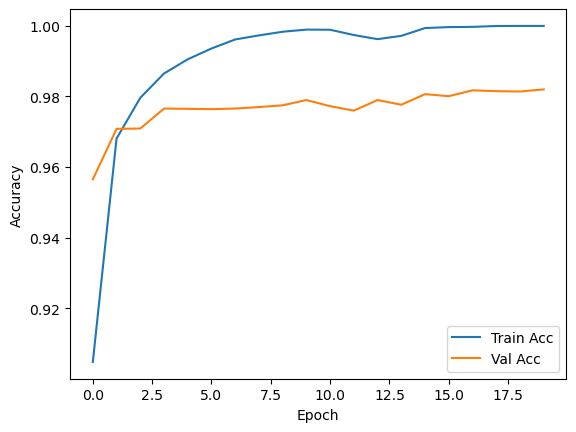

In [11]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The training accuracy increased fast and reached 100%, means the model learned the patterns in the training images very well. Meanwhile, the validation accuracy stayed slightly lower, around 97–98%, which confirms that the model also performs well on data it hasn’t seen during training.

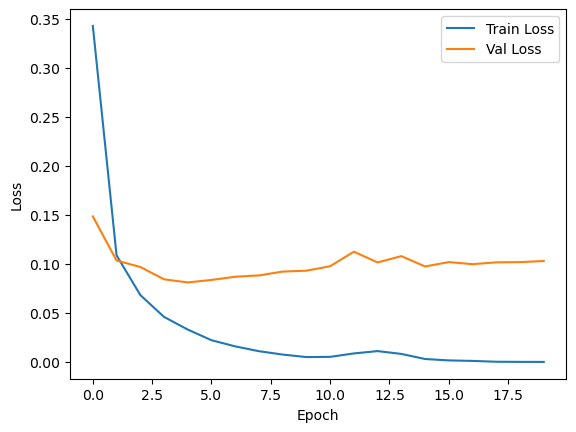

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The training loss kept decreasing and became almost zero, indicating that the model was learning effectively. At the same time, the validation loss dropped at the beginning and then stabilized with only small fluctuations. Overall, these results suggest that the ANN performs well and is able to classify handwritten digits with high accuracy.